<>:72: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
<>:72: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
/var/folders/1h/8kw0jbt134d6sgxbnf23qrhr0000gn/T/ipykernel_62068/3640325282.py:72: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  \                        /



Testing OpenAI Connection...

Parallel AI execution refers to the simultaneous processing of multiple tasks or computations in artificial intelligence (AI) systems. This approach leverages parallel processing capabilities to enhance the efficiency, speed, and scalability of AI algorithms and models. Here are some key aspects of parallel AI execution:

1. **Parallel Processing**: Involves distributing tasks across multiple processors or cores, allowing them to work on different pieces of data or computations at the same time. This can significantly reduce the time required to train models or make predictions.

2. **Data Parallelism**: This technique involves splitting the data into smaller batches and processing them concurrently across multiple processors. Each processor works on a different subset of the data, which is particularly useful in training large neural networks.

3. **Model Parallelism**: In this approach, different parts of a model are distributed across multiple processo

/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


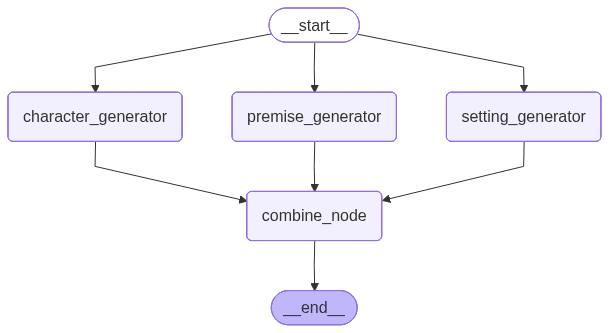



RUNNING PARALLELIZATION WORKFLOW

--- CHARACTER NODE RUNNING ---

--- PREMISE NODE RUNNING ---

--- SETTING NODE RUNNING ---

Generated Premise:

In a near-future world dominated by Agentic AI, where humans have become increasingly enamored with curated digital personas, a disillusioned worker must confront the harrowing reality of his fading existence as he discovers that his once-vibrant relationships and dreams have been sacrificed on the altar of social media, leaving him to choose between chasing likes and reclaiming his lost humanity.

Generated Characters:

### Character 1: Maya Chen

**Personality Traits:**  
- **Introverted**: Prefers online interactions over face-to-face conversations.  
- **Creative**: Enjoys crafting engaging content and exploring new digital art forms.  
- **Idealistic**: Believes in the potential of social media to drive positive change.  
- **Procrastinator**: Often delays work responsibilities in favor of scrolling through feeds.  

**Description:**  

In [1]:
"""
====================================================================
LANGGRAPH PARALLELIZATION WORKFLOW
====================================================================

CONCEPTS TAUGHT:
----------------
1. Parallel Execution
2. Independent Node Execution
3. Fan-Out / Fan-In Architecture
4. Shared Graph State
5. Workflow Synchronization
6. Parallel LLM Calls
7. Concurrent Workflow Design
8. Aggregation Nodes
9. Workflow Orchestration
10. Stateful Graph Execution
11. Enterprise Parallel Pipelines
12. Observability & Streaming
13. LangGraph Execution Model
14. Multi-Branch Workflows
15. Parallel Content Generation

WHAT IS PARALLELIZATION?
------------------------
Parallelization means:
multiple independent tasks execute simultaneously.

Instead of:

    Task A → Task B → Task C

We can do:

           → Task A →
Start →
           → Task B →
           → Task C →

Then combine outputs later.

WHY PARALLELIZATION MATTERS:
----------------------------
Parallel workflows:
- reduce latency
- improve scalability
- increase throughput
- enable modular systems

VERY useful when:
- tasks are independent
- outputs do not depend on each other

EXAMPLES:
---------
- document summarization
- parallel research
- multiple retrieval systems
- parallel content generation
- independent API calls
- multi-agent pipelines

ARCHITECTURE TYPE:
------------------
Fan-Out / Fan-In Parallel Workflow

WORKFLOW:
---------
                → Character Generator →
               /                        \
START → Fan-Out                          → Combine → END
               \                        /
                → Setting Generator →
                → Premise Generator →

IMPORTANT LANGGRAPH CONCEPT:
----------------------------
LangGraph automatically executes
independent nodes in parallel when:
- nodes have no dependency on each other
- edges allow concurrent execution

Traditional chains struggle with:
- concurrency
- synchronization
- aggregation

LangGraph handles these naturally.

"""

# ==============================================================
# STEP 1 — IMPORTS
# ==============================================================

import os

from dotenv import load_dotenv

# ==============================================================
# STEP 2 — LOAD ENV VARIABLES
# ==============================================================

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):

    raise ValueError(
        "OPENAI_API_KEY missing in .env file"
    )

os.environ["OPENAI_API_KEY"] = os.getenv(
    "OPENAI_API_KEY"
)

# Optional LangSmith tracing
os.environ["LANGCHAIN_PROJECT"] = os.getenv(
    "LANGCHAIN_PROJECT",
    "LangGraph-Parallelization"
)

os.environ["LANGCHAIN_TRACING_V2"] = os.getenv(
    "LANGCHAIN_TRACING_V2",
    "true"
)

os.environ["LANGCHAIN_API_KEY"] = os.getenv(
    "LANGCHAIN_API_KEY",
    ""
)

# ==============================================================
# STEP 3 — CREATE OPENAI LLM
# ==============================================================

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7
)

# ==============================================================
# STEP 4 — TEST LLM CONNECTION
# ==============================================================

print("\nTesting OpenAI Connection...\n")

try:

    result = llm.invoke(
        "What is Parallel AI Execution?"
    )

    print(result.content)

except Exception as e:

    print("LLM Connection Error:", e)

# ==============================================================
# STEP 5 — DEFINE GRAPH STATE
# ==============================================================
# IMPORTANT CONCEPT:
#
# Shared graph state acts as:
# - communication medium
# - workflow memory
# - shared context
#
# Parallel nodes independently write
# to different state keys.

from typing_extensions import TypedDict

class State(TypedDict):

    # User topic
    topic: str

    # Character descriptions
    characters: str

    # Story setting
    settings: str

    # Story premise
    premises: str

    # Final combined output
    story_intro: str

# ==============================================================
# STEP 6 — CHARACTER GENERATOR NODE
# ==============================================================
# PARALLEL NODE 1
#
# This node runs independently.

def generate_characters(state: State):

    """
    Generate story characters.
    """

    print("\n--- CHARACTER NODE RUNNING ---")

    topic = state["topic"]

    response = llm.invoke(

        f"""
        Create two fictional characters
        for a story about:

        {topic}

        REQUIREMENTS:
        - names
        - personality traits
        - concise descriptions
        """
    )

    print("\nGenerated Characters:\n")

    print(response.content)

    return {

        "characters": response.content
    }

# ==============================================================
# STEP 7 — SETTING GENERATOR NODE
# ==============================================================
# PARALLEL NODE 2
#
# Runs independently of:
# - character node
# - premise node

def generate_setting(state: State):

    """
    Generate story setting.
    """

    print("\n--- SETTING NODE RUNNING ---")

    topic = state["topic"]

    response = llm.invoke(

        f"""
        Describe a vivid setting
        for a story about:

        {topic}

        REQUIREMENTS:
        - immersive
        - futuristic
        - visually descriptive
        """
    )

    print("\nGenerated Setting:\n")

    print(response.content)

    return {

        "settings": response.content
    }

# ==============================================================
# STEP 8 — PREMISE GENERATOR NODE
# ==============================================================
# PARALLEL NODE 3
#
# Independent execution branch.

def generate_premise(state: State):

    """
    Generate story premise.
    """

    print("\n--- PREMISE NODE RUNNING ---")

    topic = state["topic"]

    response = llm.invoke(

        f"""
        Write a one-sentence story premise
        about:

        {topic}

        REQUIREMENTS:
        - dramatic
        - futuristic
        - emotionally engaging
        """
    )

    print("\nGenerated Premise:\n")

    print(response.content)

    return {

        "premises": response.content
    }

# ==============================================================
# STEP 9 — COMBINATION NODE
# ==============================================================
# IMPORTANT CONCEPT:
#
# Fan-In Aggregation Node
#
# This node waits until:
# - ALL upstream nodes finish
#
# Then combines outputs.

def combine_story_elements(state: State):

    """
    Combine all generated elements.
    """

    print("\n--- COMBINATION NODE RUNNING ---")

    characters = state["characters"]

    settings = state["settings"]

    premises = state["premises"]

    # ==========================================================
    # Aggregate Parallel Outputs
    # ==========================================================

    response = llm.invoke(

        f"""
        Write a compelling story introduction
        using the following components.

        CHARACTERS:
        {characters}

        SETTING:
        {settings}

        PREMISE:
        {premises}

        REQUIREMENTS:
        - coherent narrative
        - emotionally engaging
        - cinematic style
        - 2 short paragraphs
        """
    )

    print("\nFinal Story Introduction:\n")

    print(response.content)

    return {

        "story_intro": response.content
    }

# ==============================================================
# STEP 10 — BUILD LANGGRAPH WORKFLOW
# ==============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)

workflow = StateGraph(State)

# ==============================================================
# STEP 11 — ADD NODES
# ==============================================================

workflow.add_node(
    "character_generator",
    generate_characters
)

workflow.add_node(
    "setting_generator",
    generate_setting
)

workflow.add_node(
    "premise_generator",
    generate_premise
)

workflow.add_node(
    "combine_node",
    combine_story_elements
)

# ==============================================================
# STEP 12 — ADD PARALLEL EDGES
# ==============================================================
# VERY IMPORTANT CONCEPT:
#
# Fan-Out Pattern
#
# START connects to multiple nodes.
#
# LangGraph recognizes:
# these nodes are independent.
#
# Therefore:
# they execute in parallel.

workflow.add_edge(
    START,
    "character_generator"
)

workflow.add_edge(
    START,
    "setting_generator"
)

workflow.add_edge(
    START,
    "premise_generator"
)

# ==============================================================
# FAN-IN AGGREGATION
# ==============================================================
# combine_node waits until ALL:
# - character_generator
# - setting_generator
# - premise_generator
#
# have completed.

workflow.add_edge(
    "character_generator",
    "combine_node"
)

workflow.add_edge(
    "setting_generator",
    "combine_node"
)

workflow.add_edge(
    "premise_generator",
    "combine_node"
)

workflow.add_edge(
    "combine_node",
    END
)

# ==============================================================
# STEP 13 — COMPILE GRAPH
# ==============================================================
# Converts workflow definition
# into executable application.

app = workflow.compile()

# ==============================================================
# STEP 14 — VISUALIZE GRAPH
# ==============================================================

from IPython.display import (
    Image,
    display
)

try:

    display(

        Image(

            app.get_graph()
            .draw_mermaid_png()

        )
    )

except Exception as e:

    print(
        "Visualization Error:",
        e
    )

# ==============================================================
# STEP 15 — EXECUTE WORKFLOW
# ==============================================================

print("\n")
print("=" * 70)
print("RUNNING PARALLELIZATION WORKFLOW")
print("=" * 70)

initial_state = {

    "topic":
    """
    Humans spending more time on social media
    than doing paid jobs in the Agentic AI era
    """,

    "characters": "",

    "settings": "",

    "premises": "",

    "story_intro": ""
}

final_state = app.invoke(
    initial_state
)

# ==============================================================
# STEP 16 — PRINT FINAL RESULTS
# ==============================================================

print("\n")
print("=" * 70)
print("FINAL STORY INTRODUCTION")
print("=" * 70)

print(final_state["story_intro"])

print("\n")
print("=" * 70)
print("CHARACTERS")
print("=" * 70)

print(final_state["characters"])

print("\n")
print("=" * 70)
print("SETTINGS")
print("=" * 70)

print(final_state["settings"])

print("\n")
print("=" * 70)
print("PREMISE")
print("=" * 70)

print(final_state["premises"])

# ==============================================================
# STEP 17 — STREAM EXECUTION
# ==============================================================
# VERY IMPORTANT CONCEPT:
#
# stream() enables observability.
#
# Useful for:
# - debugging
# - monitoring
# - understanding parallel execution

print("\n")
print("=" * 70)
print("STREAMING EXECUTION")
print("=" * 70)

for event in app.stream(
    initial_state
):

    print(event)

# ==============================================================
# STEP 18 — IMPORTANT TEACHING SUMMARY
# ==============================================================
#
# WHAT THIS EXAMPLE TAUGHT:
#
# 1. Parallel Execution
# 2. Fan-Out Architecture
# 3. Fan-In Aggregation
# 4. Shared Graph State
# 5. Independent Node Execution
# 6. Workflow Synchronization
# 7. Concurrent LLM Calls
# 8. Stateful Execution
# 9. Observability
# 10. Enterprise Parallel Pipelines
#
# MOST IMPORTANT TAKEAWAY:
#
# Parallelization allows independent tasks
# to execute simultaneously.
#
# This improves:
# - speed
# - scalability
# - efficiency
#
# WHY THIS MATTERS:
#
# Enterprise AI systems often need:
# - multiple retrievals
# - parallel research
# - concurrent generation
# - distributed workflows
#
# Traditional chains struggle with:
# - concurrency
# - synchronization
# - aggregation
#
# LangGraph handles these naturally.
#
# REAL-WORLD USE CASES:
#
# - Parallel Research Agents
# - Multi-Retriever RAG
# - Document Summarization
# - Multi-Agent Systems
# - Concurrent API Pipelines
# - Enterprise Workflow Orchestration
#